In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =============================
# LOAD DATA
# =============================
df = pd.read_csv("../final_dual_fluid_shell_tube_dataset.csv")

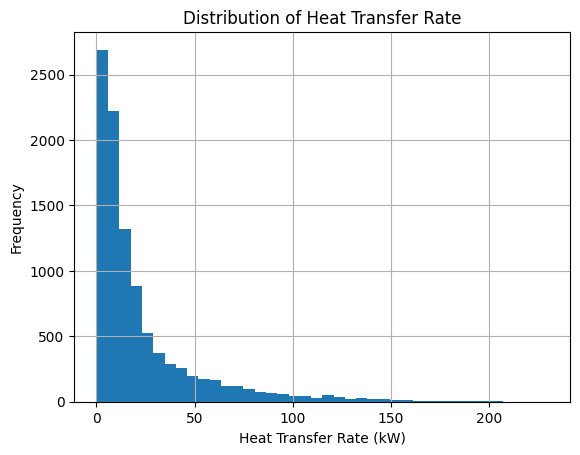

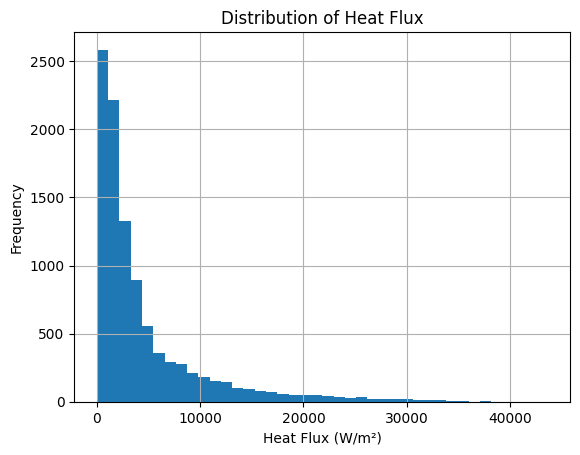

In [2]:
# =============================
# 1️⃣ TARGET DISTRIBUTIONS
# =============================
plt.figure()
plt.hist(df["heat_transfer_rate"] / 1000, bins=40)
plt.xlabel("Heat Transfer Rate (kW)")
plt.ylabel("Frequency")
plt.title("Distribution of Heat Transfer Rate")
plt.grid(True)
plt.show()

plt.figure()
plt.hist(df["heat_flux"], bins=40)
plt.xlabel("Heat Flux (W/m²)")
plt.ylabel("Frequency")
plt.title("Distribution of Heat Flux")
plt.grid(True)
plt.show()

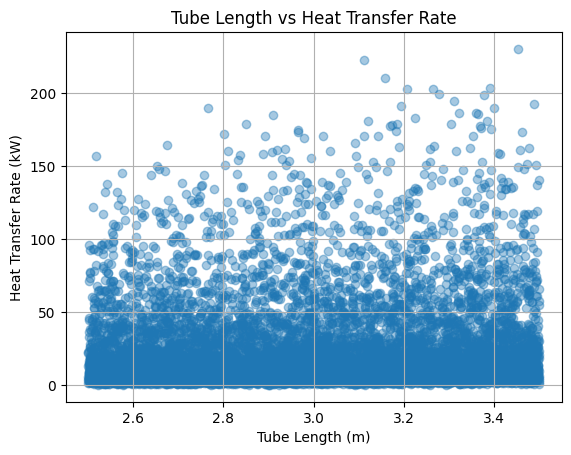

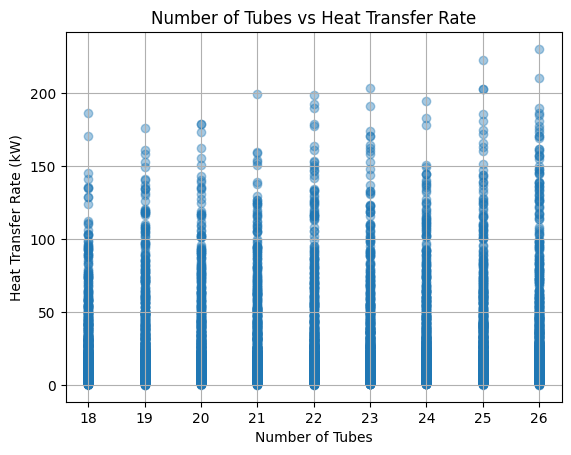

In [3]:
# =============================
# 2️⃣ GEOMETRY vs PERFORMANCE
# =============================
plt.figure()
plt.scatter(df["tube_length"], df["heat_transfer_rate"] / 1000, alpha=0.4)
plt.xlabel("Tube Length (m)")
plt.ylabel("Heat Transfer Rate (kW)")
plt.title("Tube Length vs Heat Transfer Rate")
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(df["number_of_tubes"], df["heat_transfer_rate"] / 1000, alpha=0.4)
plt.xlabel("Number of Tubes")
plt.ylabel("Heat Transfer Rate (kW)")
plt.title("Number of Tubes vs Heat Transfer Rate")
plt.grid(True)
plt.show()

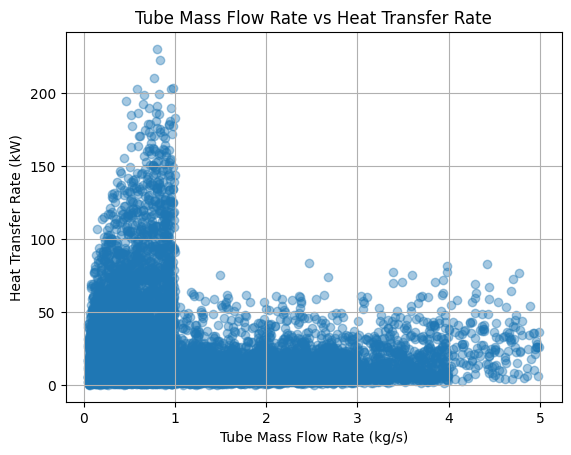

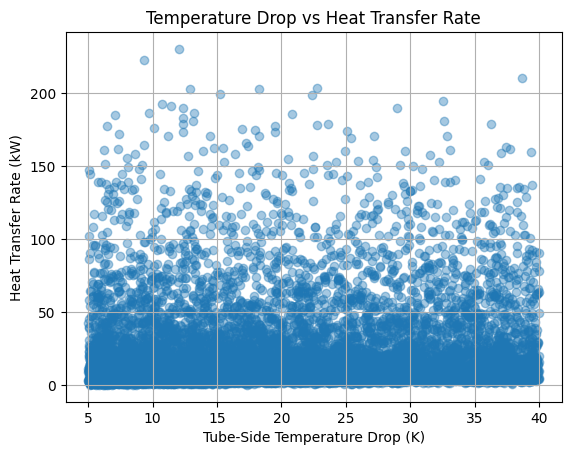

In [4]:
# =============================
# 3️⃣ OPERATING CONDITIONS
# =============================
plt.figure()
plt.scatter(df["tube_mass_flow_rate"], df["heat_transfer_rate"] / 1000, alpha=0.4)
plt.xlabel("Tube Mass Flow Rate (kg/s)")
plt.ylabel("Heat Transfer Rate (kW)")
plt.title("Tube Mass Flow Rate vs Heat Transfer Rate")
plt.grid(True)
plt.show()

delta_T = df["tube_inlet_temp"] - df["tube_outlet_temp"]

plt.figure()
plt.scatter(delta_T, df["heat_transfer_rate"] / 1000, alpha=0.4)
plt.xlabel("Tube-Side Temperature Drop (K)")
plt.ylabel("Heat Transfer Rate (kW)")
plt.title("Temperature Drop vs Heat Transfer Rate")
plt.grid(True)
plt.show()

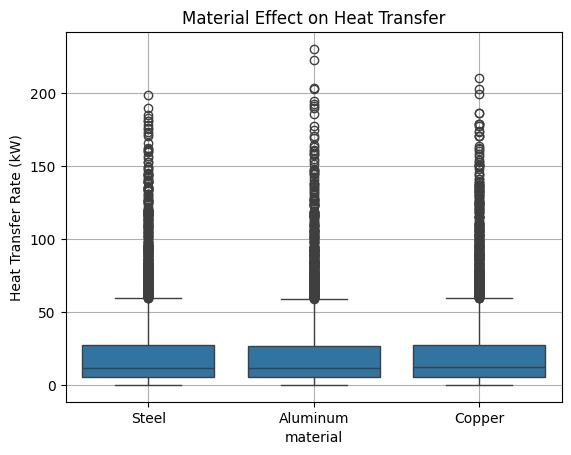

In [5]:
# =============================
# 4️⃣ MATERIAL EFFECT
# =============================
def classify_material(k):
    if k < 50:
        return "Steel"
    elif k < 300:
        return "Aluminum"
    else:
        return "Copper"

df["material"] = df["tube_thermal_conductivity"].apply(classify_material)

plt.figure()
sns.boxplot(x="material", y=df["heat_transfer_rate"] / 1000, data=df)
plt.ylabel("Heat Transfer Rate (kW)")
plt.title("Material Effect on Heat Transfer")
plt.grid(True)
plt.show()

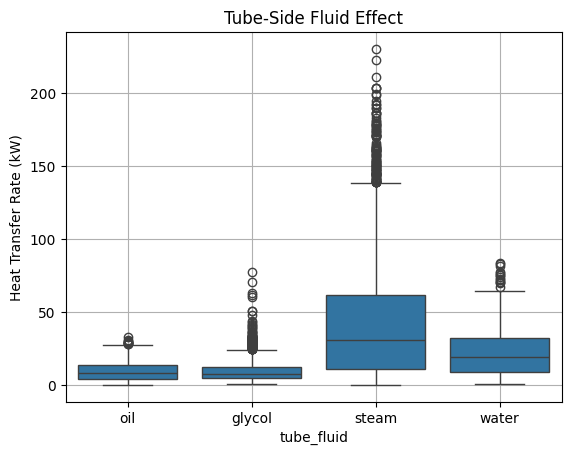

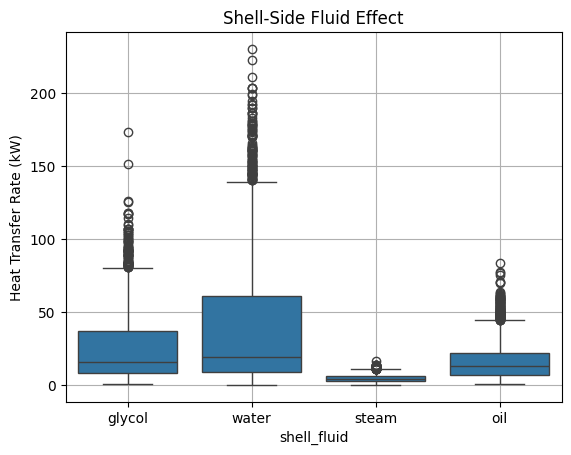

In [6]:
# =============================
# 5️⃣ FLUID EFFECTS
# =============================
plt.figure()
sns.boxplot(x="tube_fluid", y=df["heat_transfer_rate"] / 1000, data=df)
plt.ylabel("Heat Transfer Rate (kW)")
plt.title("Tube-Side Fluid Effect")
plt.grid(True)
plt.show()

plt.figure()
sns.boxplot(x="shell_fluid", y=df["heat_transfer_rate"] / 1000, data=df)
plt.ylabel("Heat Transfer Rate (kW)")
plt.title("Shell-Side Fluid Effect")
plt.grid(True)
plt.show()

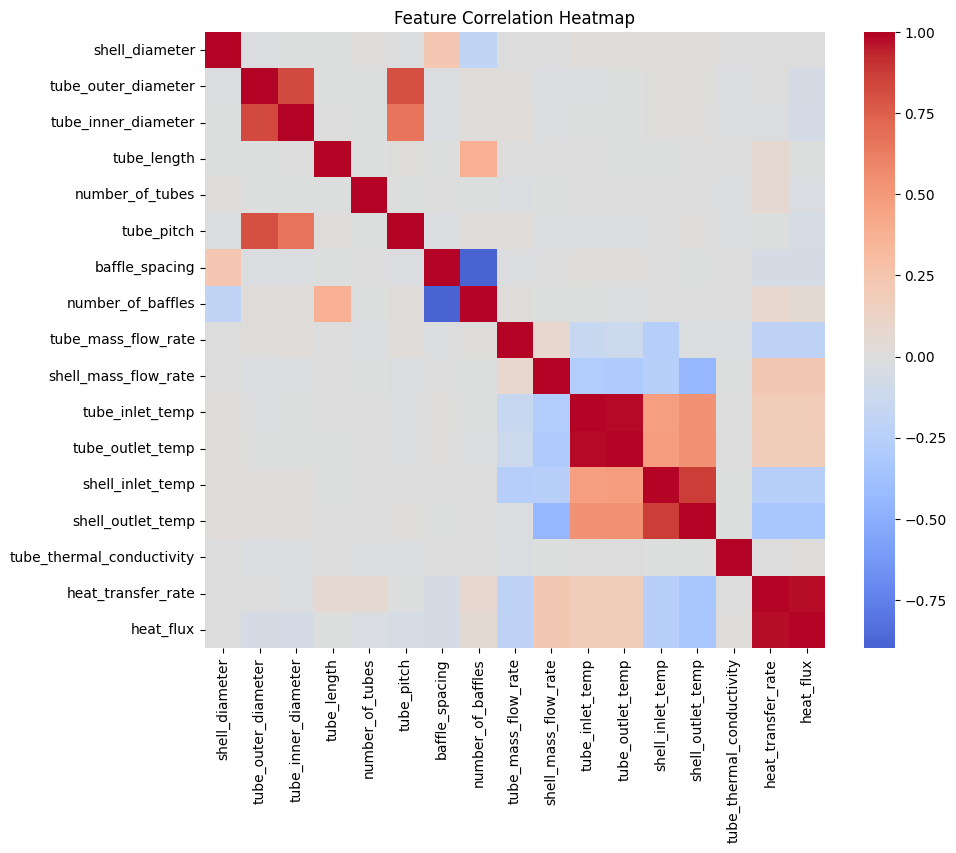

In [7]:
# =============================
# 6️⃣ CORRELATION HEATMAP
# =============================
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()